# Data Quality & Exploratory Data Analysis

This notebook assesses the quality and coverage of the collected data:
- **Tweets** scraped from X (Twitter) via Playwright
- **Price snapshots** (1-minute intraday) stored alongside tweets
- **Historical OHLCV prices** downloaded via yfinance

Goal: Identify data gaps, coverage issues, and basic statistics before sentiment analysis.

## 1 — Setup & Data Loading

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("..") / "data"
DB_PATH = DATA_DIR / "webmining.db"
PRICES_CSV = DATA_DIR / "raw" / "prices" / "prices.csv"

# ---- SQLite tables ----
conn = sqlite3.connect(DB_PATH)

tweets = pd.read_sql("SELECT * FROM tweets", conn)
snapshots = pd.read_sql("SELECT * FROM tweet_snapshots", conn)
price_snaps = pd.read_sql("SELECT * FROM price_snapshots", conn)

conn.close()

# ---- CSV price history ----
prices = pd.read_csv(PRICES_CSV)

# Parse dates
tweets["posted_at"] = pd.to_datetime(tweets["posted_at"])
price_snaps["timestamp"] = pd.to_datetime(price_snaps["timestamp"])
prices["Date"] = pd.to_datetime(prices["Date"])

print(f"Tweets:           {len(tweets):>6,}")
print(f"Tweet snapshots:  {len(snapshots):>6,}")
print(f"Price snapshots:  {len(price_snaps):>6,}")
print(f"Prices (CSV):     {len(prices):>6,}")

Tweets:            1,139
Tweet snapshots:   1,139
Price snapshots:  15,803
Prices (CSV):      3,927


## 2 — Tweet Data Overview

In [2]:
# Basic statistics
n_total = len(tweets)
n_with_symbol = tweets["symbol"].notna().sum()
n_without_symbol = n_total - n_with_symbol

print(f"Total tweets:       {n_total}")
print(f"With cashtag:       {n_with_symbol} ({n_with_symbol/n_total:.1%})")
print(f"Without cashtag:    {n_without_symbol} ({n_without_symbol/n_total:.1%})")
print(f"Unique symbols:     {tweets['symbol'].nunique()}")
print(f"Unique authors:     {tweets['author'].nunique()}")
print(f"Date range:         {tweets['posted_at'].min():%Y-%m-%d} → {tweets['posted_at'].max():%Y-%m-%d}")

Total tweets:       1139
With cashtag:       515 (45.2%)
Without cashtag:    624 (54.8%)
Unique symbols:     58
Unique authors:     595
Date range:         2016-04-26 → 2026-04-17


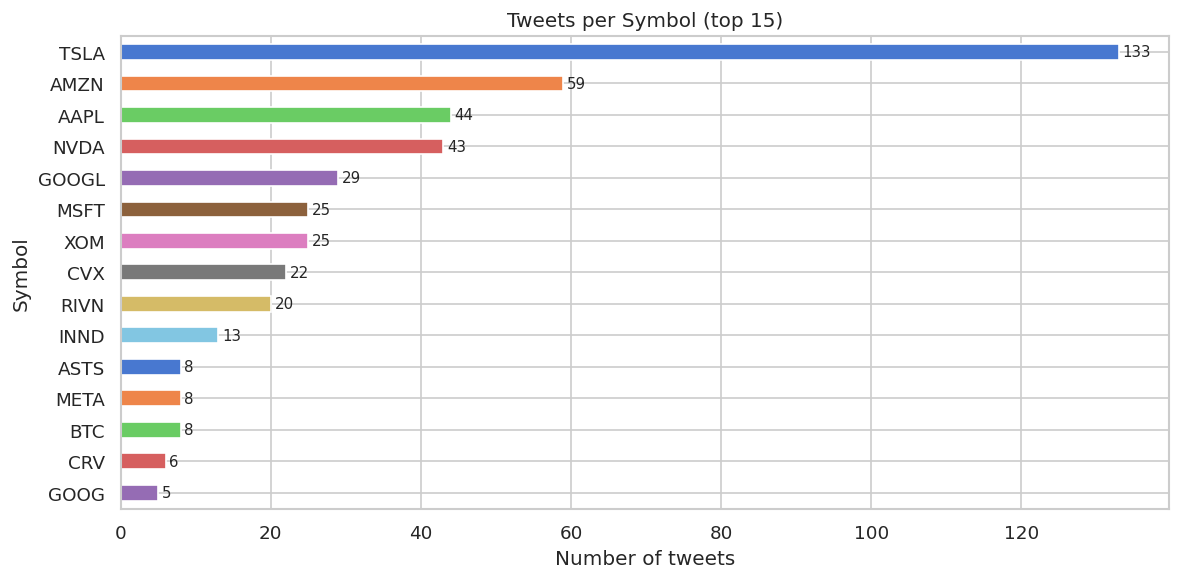

In [3]:
# Tweets per symbol (top 15)
symbol_counts = tweets["symbol"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
symbol_counts.plot.barh(ax=ax, color=sns.color_palette("muted", len(symbol_counts)))
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Symbol")
ax.set_title("Tweets per Symbol (top 15)")
ax.invert_yaxis()
for i, v in enumerate(symbol_counts.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

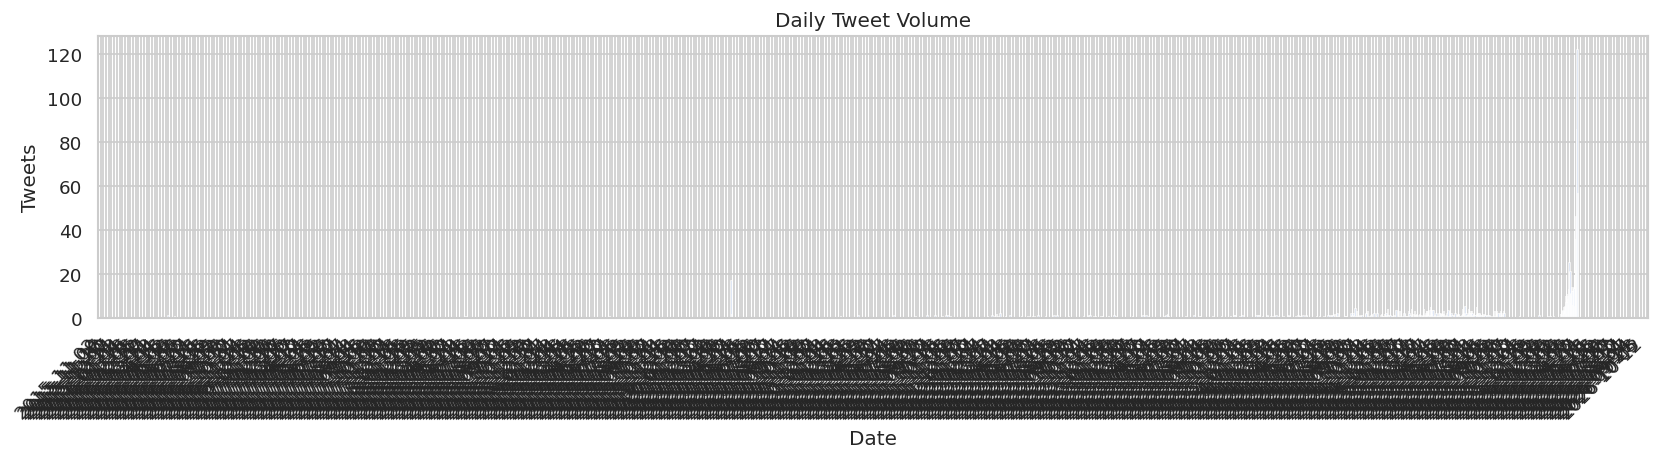

In [4]:
# Temporal distribution of tweets (daily)
tweets["date"] = tweets["posted_at"].dt.date
daily_counts = tweets.groupby("date").size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_counts.index, daily_counts.values, width=1, alpha=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets")
ax.set_title("Daily Tweet Volume")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Follower & engagement stats
merged = tweets.merge(snapshots, on="tweet_id", how="left")

print("Follower count statistics:")
print(tweets["author_followers"].describe().to_string())
print()
print("Engagement statistics (likes / retweets):")
print(merged[["likes", "retweets"]].describe().to_string())

Follower count statistics:
count    1.139000e+03
mean     3.762119e+05
std      1.156313e+06
min      1.000000e+02
25%      1.470000e+04
50%      6.570000e+04
75%      3.651000e+05
max      1.390000e+07

Engagement statistics (likes / retweets):
              likes      retweets
count   1139.000000   1139.000000
mean     700.748025    129.233538
std     1591.224990    508.718900
min        0.000000      0.000000
25%      152.500000     16.000000
50%      303.000000     37.000000
75%      742.000000    107.000000
max    33000.000000  13000.000000


### 2.1 — Duplicate & Empty Text Check

In [ ]:
# Duplicate & empty text check
n_dup_id = tweets['tweet_id'].duplicated().sum()
n_dup_content = tweets['content'].duplicated().sum()
n_empty = tweets['content'].isna().sum() + (tweets['content'].str.strip() == '').sum()

print(f"Duplicate tweet_ids:    {n_dup_id}")
print(f"Duplicate content:      {n_dup_content}")
print(f"Empty / NaN content:    {n_empty}")

if n_dup_content > 0:
    print(f"\nMost repeated content (top 5):")
    dup_content = tweets[tweets['content'].duplicated(keep=False)]
    print(dup_content['content'].value_counts().head(5).to_string())

### 2.2 — Language Detection

In [ ]:
# Language detection on tweet content
from langdetect import detect, LangDetectException
from langdetect import DetectorFactory
DetectorFactory.seed = 42  # reproducibility

def safe_detect(text: str) -> str:
    try:
        return detect(text)
    except (LangDetectException, TypeError):
        return "unknown"

tweets["lang"] = tweets["content"].apply(safe_detect)

lang_counts = tweets["lang"].value_counts()
print(f"Detected languages ({len(lang_counts)} total):")
print(lang_counts.head(10).to_string())
print(f"\nEnglish share: {(tweets['lang'] == 'en').mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
lang_counts.head(10).plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Language")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Language Distribution (top 10)")
plt.tight_layout()
plt.show()

### 2.3 — Engagement Distribution: Viral vs. Normal

In [ ]:
# Engagement distribution with viral threshold
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

p95 = merged["total_engagement"].quantile(0.95)
p99 = merged["total_engagement"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 4))
merged["total_engagement"].clip(lower=0).hist(
    bins=50, ax=ax, color="steelblue", alpha=0.7, log=True
)
ax.axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95 = {p95:.0f}")
ax.axvline(p99, color="red", linestyle="--", linewidth=1.5, label=f"P99 = {p99:.0f}")
ax.set_xlabel("Total Engagement (likes + retweets)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Engagement Distribution — Viral vs. Normal")
ax.legend()
plt.tight_layout()
plt.show()

n_viral = (merged["total_engagement"] >= p95).sum()
print(f"Viral threshold (P95): {p95:.0f}")
print(f"Viral tweets (≥P95):   {n_viral} ({n_viral/len(merged):.1%})")
print(f"P99 threshold:         {p99:.0f}")

## 3 — Price Snapshot Coverage

In [6]:
# How many tweets have associated price snapshots?
tweet_ids_with_prices = price_snaps["tweet_id"].unique()
n_with_prices = tweets["tweet_id"].isin(tweet_ids_with_prices).sum()
n_without_prices = len(tweets) - n_with_prices

print(f"Tweets with price data:    {n_with_prices} ({n_with_prices/len(tweets):.1%})")
print(f"Tweets without price data: {n_without_prices} ({n_without_prices/len(tweets):.1%})")
print(f"Average price snapshots per tweet (where available): "
      f"{price_snaps.groupby('tweet_id').size().mean():.1f}")
print(f"Total price snapshot rows: {len(price_snaps):,}")

Tweets with price data:    151 (13.3%)
Tweets without price data: 988 (86.7%)
Average price snapshots per tweet (where available): 104.7
Total price snapshot rows: 15,803


In [7]:
# Price snapshot coverage per symbol
tweets_with_price_flag = tweets.copy()
tweets_with_price_flag["has_price"] = tweets["tweet_id"].isin(tweet_ids_with_prices)
coverage = (
    tweets_with_price_flag[tweets_with_price_flag["symbol"].notna()]
    .groupby("symbol")["has_price"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_price", "count": "total"})
    .assign(pct=lambda d: d["with_price"] / d["total"])
    .sort_values("total", ascending=False)
    .head(15)
)
print(coverage.to_string())

        with_price  total       pct
symbol                             
TSLA            52    133  0.390977
AMZN            18     59  0.305085
AAPL             7     44  0.159091
NVDA             9     43  0.209302
GOOGL           20     29  0.689655
XOM              0     25  0.000000
MSFT            13     25  0.520000
CVX              1     22  0.045455
RIVN             0     20  0.000000
INND             0     13  0.000000
ASTS             4      8  0.500000
BTC              1      8  0.125000
META             3      8  0.375000
CRV              0      6  0.000000
GOOG             2      5  0.400000


## 4 — Historical Price Data (CSV) Quality

In [8]:
print(f"Rows: {len(prices):,}")
print(f"Tickers: {sorted(prices['Ticker'].unique())}")
print(f"Date range: {prices['Date'].min():%Y-%m-%d} → {prices['Date'].max():%Y-%m-%d}")
print(f"Missing values:\n{prices.isnull().sum().to_string()}")
print()

# Rows per ticker
rows_per_ticker = prices.groupby("Ticker").agg(
    rows=("Date", "count"),
    first_date=("Date", "min"),
    last_date=("Date", "max"),
)
print("Rows per ticker:")
print(rows_per_ticker.to_string())

Rows: 3,927
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2024-01-02 → 2026-03-27
Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0

Rows per ticker:
        rows first_date  last_date
Ticker                            
AAPL     561 2024-01-02 2026-03-27
AMZN     561 2024-01-02 2026-03-27
GOOGL    561 2024-01-02 2026-03-27
META     561 2024-01-02 2026-03-27
MSFT     561 2024-01-02 2026-03-27
NVDA     561 2024-01-02 2026-03-27
TSLA     561 2024-01-02 2026-03-27


In [9]:
# Basic price statistics per ticker
price_stats = prices.groupby("Ticker")["Adj Close"].describe()
print(price_stats.to_string())

        count        mean         std         min         25%         50%         75%         max
Ticker                                                                                           
AAPL    561.0  222.963505   30.520590  163.511917  200.390213  224.415833  246.612839  285.922455
AMZN    561.0  203.147986   23.924227  144.570007  183.630005  205.020004  223.809998  254.000000
GOOGL   561.0  199.968445   58.126495  130.322876  161.795700  175.055496  233.722473  343.448242
META    561.0  592.671304  100.552432  341.787842  506.148682  596.150208  665.460022  788.148987
MSFT    561.0  436.221114   44.186263  351.866211  404.256165  420.758728  475.279053  539.825256
NVDA    561.0  136.326184   38.290048   47.539940  110.903862  134.756561  176.950562  207.017273
TSLA    561.0  306.167201   97.067872  142.050003  218.850006  309.260010  400.989990  489.880005


### 4.1 — Missing Trading Days

In [ ]:
# Check for missing NYSE trading days in the price data
import exchange_calendars as xcals

tickers = sorted(prices["Ticker"].unique())

xnys = xcals.get_calendar("XNYS")
price_start = prices["Date"].min()
price_end = prices["Date"].max()
trading_days = xnys.sessions_in_range(price_start, price_end)

print(f"NYSE trading days in range: {len(trading_days)}")

missing_per_ticker = {}
for ticker in tickers:
    ticker_dates = set(prices[prices['Ticker'] == ticker]['Date'].dt.normalize())
    missing = sorted(set(trading_days) - ticker_dates)
    missing_per_ticker[ticker] = missing

missing_df = pd.DataFrame([
    {"Ticker": t, "expected": len(trading_days), "present": len(trading_days) - len(m),
     "missing": len(m), "pct_complete": (len(trading_days) - len(m)) / len(trading_days)}
    for t, m in missing_per_ticker.items()
])
print("\nTrading day completeness per ticker:")
print(missing_df.to_string(index=False))

# Show first few missing dates if any
for t, m in missing_per_ticker.items():
    if m:
        preview = [d.strftime('%Y-%m-%d') for d in m[:5]]
        suffix = f' ... (+{len(m)-5} more)' if len(m) > 5 else ''
        print(f"  {t} missing: {', '.join(preview)}{suffix}")

### 4.2 — Daily Returns & Outlier Detection

In [ ]:
# Calculate daily returns and detect outliers
prices_sorted = prices.sort_values(["Ticker", "Date"])
prices_sorted["return_pct"] = (
    prices_sorted.groupby("Ticker")["Adj Close"].pct_change() * 100
)

# IQR-based outlier detection per ticker using transform (avoids index issues)
def iqr_outlier(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)

prices_sorted["is_outlier"] = prices_sorted.groupby("Ticker")["return_pct"].transform(iqr_outlier)

n_outliers = prices_sorted["is_outlier"].sum()
print(f"Outlier returns (IQR×3): {n_outliers} of {prices_sorted['return_pct'].notna().sum()}")

if n_outliers > 0:
    outlier_rows = prices_sorted[prices_sorted["is_outlier"]].sort_values("return_pct")
    print("\nLargest negative returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].head(5).to_string(index=False))
    print("\nLargest positive returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].tail(5).to_string(index=False))

# Boxplot of daily returns
fig, ax = plt.subplots(figsize=(10, 5))
prices_sorted.boxplot(column="return_pct", by="Ticker", ax=ax, sym="r.")
ax.set_title("Daily Return Distribution by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Daily Return (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 — Returns & Rolling Volatility

In [ ]:
# Daily returns and 20-day rolling volatility
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    subset = prices_sorted[prices_sorted["Ticker"] == ticker].sort_values("Date")
    vol_20d = subset["return_pct"].rolling(20).std()

    ax.fill_between(subset["Date"], vol_20d, alpha=0.3, color="orange", label="20d vol (σ)")
    ax.bar(subset["Date"], subset["return_pct"], width=1, alpha=0.5, color="steelblue", label="Daily return")
    ax.set_ylabel("%")
    ax.set_title(ticker)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Returns & 20-Day Rolling Volatility", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4.5 — Cross-Source Alignment: Tweets ↔ Prices

In [ ]:
# 4.5a — Date range overlap (handle tz-aware vs tz-naive)
tweet_min = tweets["posted_at"].min()
tweet_max = tweets["posted_at"].max()
price_min = prices["Date"].min()
price_max = prices["Date"].max()

# Normalize to tz-naive for comparison
tweet_min_naive = tweet_min.tz_localize(None) if tweet_min.tzinfo else tweet_min
tweet_max_naive = tweet_max.tz_localize(None) if tweet_max.tzinfo else tweet_max

overlap_start = max(tweet_min_naive, price_min)
overlap_end = min(tweet_max_naive, price_max)

print(f"Tweet range:   {tweet_min_naive:%Y-%m-%d} → {tweet_max_naive:%Y-%m-%d}")
print(f"Price range:   {price_min:%Y-%m-%d} → {price_max:%Y-%m-%d}")
print(f"Overlap:       {overlap_start:%Y-%m-%d} → {overlap_end:%Y-%m-%d}")
print(f"Overlap days:  {(overlap_end - overlap_start).days}")

tweets_posted_naive = tweets["posted_at"].dt.tz_localize(None) if tweets["posted_at"].dt.tz else tweets["posted_at"]
tweets_in_overlap = tweets[
    (tweets_posted_naive >= overlap_start) & (tweets_posted_naive <= overlap_end)
]
print(f"Tweets within overlap: {len(tweets_in_overlap)} of {len(tweets)} ({len(tweets_in_overlap)/len(tweets):.1%})")

### 4.5b — Tweets on Non-Trading Days

In [ ]:
# Tweets falling on weekends or NYSE holidays
tweet_dates_norm = tweets["posted_at"].dt.tz_localize(None).dt.normalize() if tweets["posted_at"].dt.tz else tweets["posted_at"].dt.normalize()
trading_days_set = set(trading_days)

tweets["is_trading_day"] = tweet_dates_norm.isin(trading_days_set)
tweets["day_of_week"] = tweets["posted_at"].dt.day_name()

n_trading = tweets["is_trading_day"].sum()
n_non_trading = (~tweets["is_trading_day"]).sum()

print(f"Tweets on trading days:      {n_trading} ({n_trading/len(tweets):.1%})")
print(f"Tweets on non-trading days:  {n_non_trading} ({n_non_trading/len(tweets):.1%})")
print()
print("Non-trading day breakdown by weekday:")
non_td = tweets[~tweets["is_trading_day"]]
print(non_td["day_of_week"].value_counts().to_string())

### 4.5c — Exploratory Lag Analysis: Tweet Volume → Next-Day Return

In [ ]:
# Exploratory: does tweet volume on day t predict return on day t+1?
target_tickers = ["TSLA", "AAPL", "AMZN", "NVDA", "GOOGL"]
target_tickers = [t for t in target_tickers if t in tweets["symbol"].values]

fig, axes = plt.subplots(1, len(target_tickers), figsize=(4 * len(target_tickers), 4))
if len(target_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, target_tickers):
    # Daily tweet count for this ticker
    tw = tweets[tweets["symbol"] == ticker].copy()
    tw_daily = tw.groupby(tw["posted_at"].dt.tz_localize(None).dt.normalize() if tw["posted_at"].dt.tz else tw["posted_at"].dt.normalize()).size().rename("tweet_count")

    # Daily returns for this ticker
    ret = prices_sorted[prices_sorted["Ticker"] == ticker][["Date", "return_pct"]].copy()
    ret["Date"] = ret["Date"].dt.normalize()
    ret = ret.set_index("Date")["return_pct"]

    # Align: tweet volume day t → return day t+1
    combined = pd.DataFrame({"tweet_count": tw_daily, "return_t1": ret.shift(-1)}).dropna()

    if len(combined) >= 5:
        ax.scatter(combined["tweet_count"], combined["return_t1"], alpha=0.5, s=20)
        corr = combined["tweet_count"].corr(combined["return_t1"])
        ax.set_title(f"{ticker} (r={corr:.2f}, n={len(combined)})")
    else:
        ax.set_title(f"{ticker} (n<5, skip)")
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlabel("Tweet count (day t)")
    ax.set_ylabel("Return % (day t+1)")

fig.suptitle("Exploratory: Tweet Volume (t) vs. Next-Day Return (t+1)", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Coverage Matrix: Tweets with Price Data by Ticker × Week

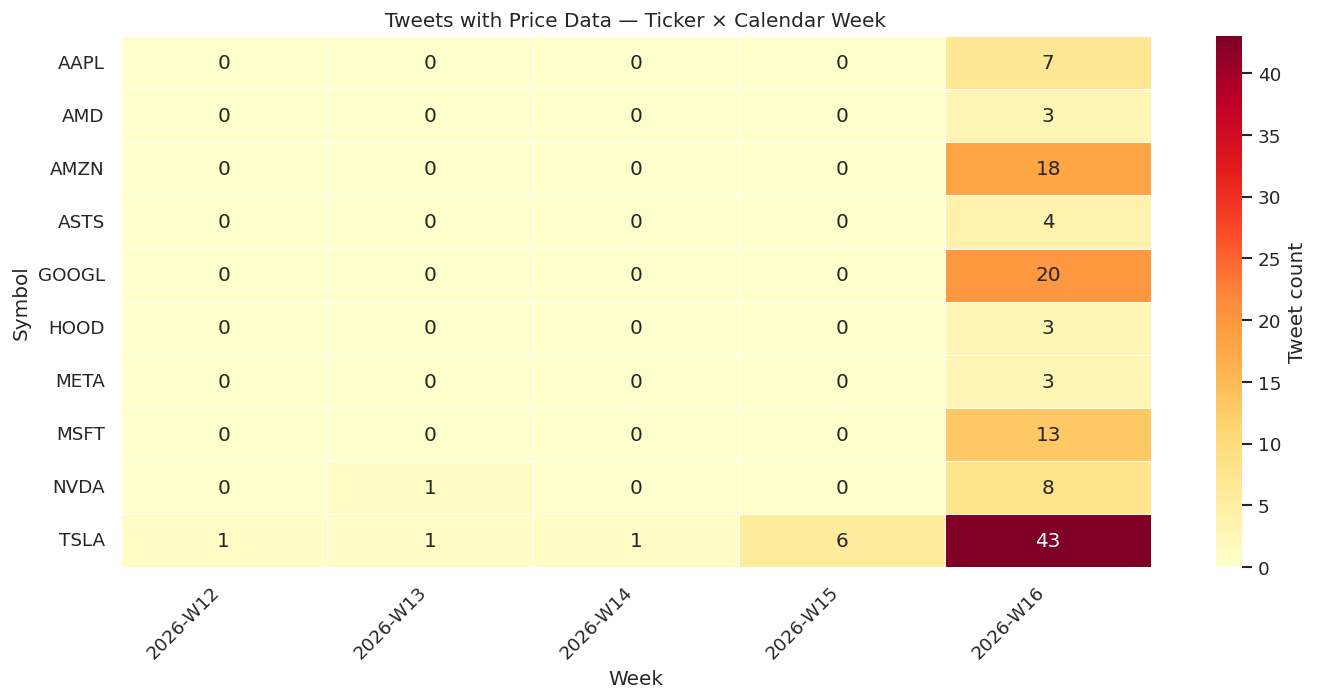

In [10]:
# Build coverage matrix for tweets that have both a symbol and price data
df_cov = tweets_with_price_flag[
    tweets_with_price_flag["symbol"].notna() & tweets_with_price_flag["has_price"]
].copy()
df_cov["week"] = df_cov["posted_at"].dt.isocalendar().week.astype(int)
df_cov["year_week"] = (
    df_cov["posted_at"].dt.isocalendar().year.astype(str)
    + "-W"
    + df_cov["week"].astype(str).str.zfill(2)
)

# Select top symbols by tweet count
top_symbols = df_cov["symbol"].value_counts().head(10).index.tolist()
df_cov_top = df_cov[df_cov["symbol"].isin(top_symbols)]

pivot = df_cov_top.pivot_table(
    index="symbol", columns="year_week", values="tweet_id", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.6), 6))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Tweet count"}
)
ax.set_title("Tweets with Price Data — Ticker × Calendar Week")
ax.set_ylabel("Symbol")
ax.set_xlabel("Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6 — Historical Price Time Series

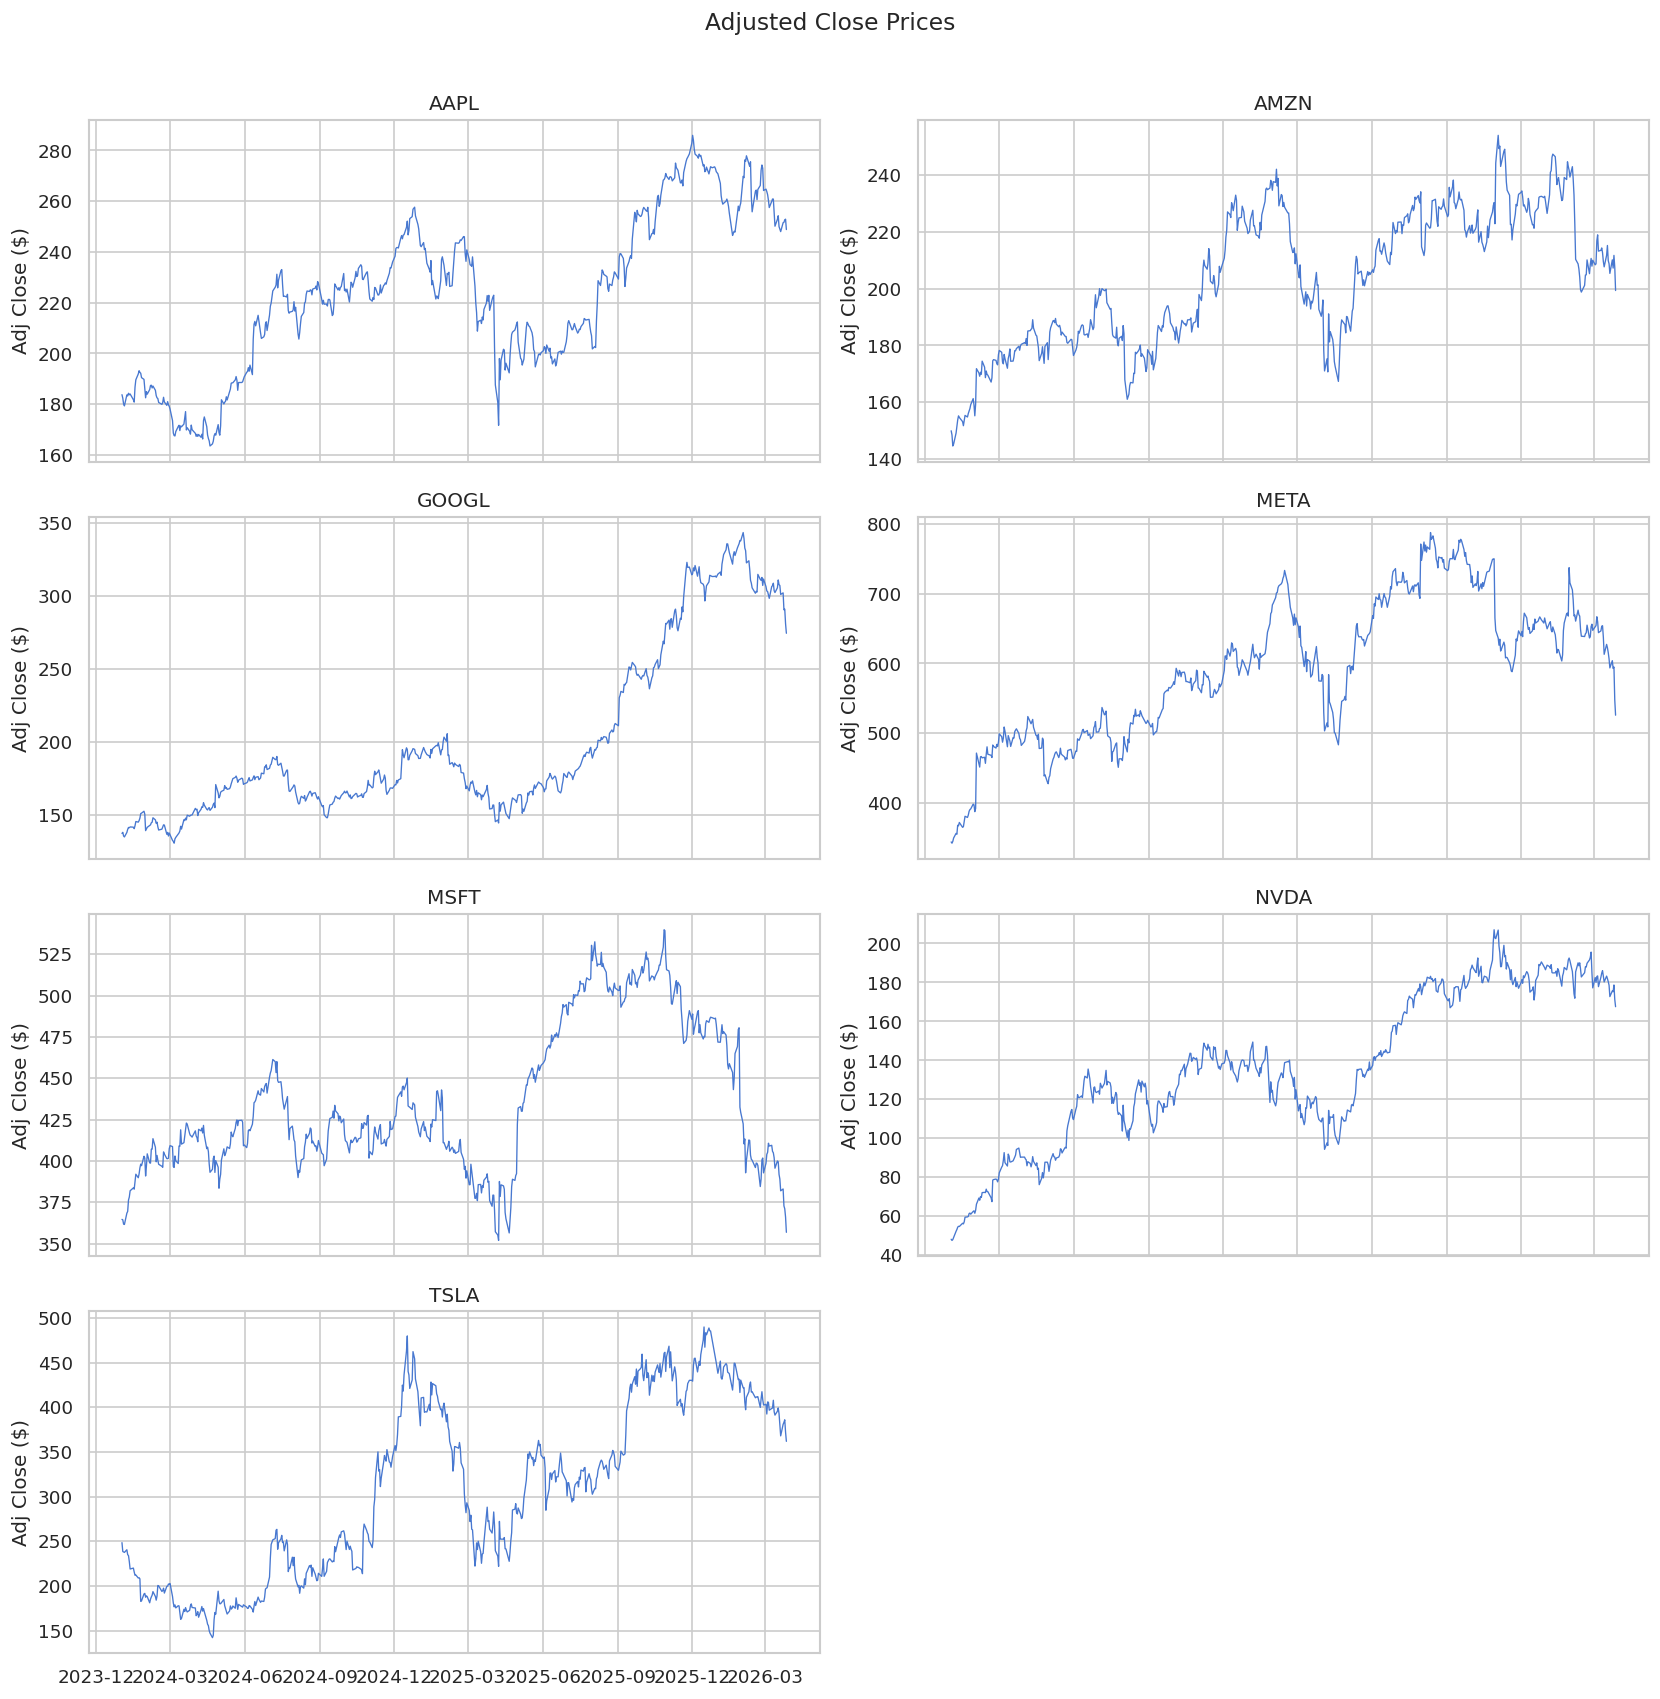

In [11]:
# Adj Close per ticker — subplots
tickers = sorted(prices["Ticker"].unique())
n_tickers = len(tickers)
ncols = 2
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    subset = prices[prices["Ticker"] == ticker]
    ax.plot(subset["Date"], subset["Adj Close"], linewidth=0.8)
    ax.set_title(ticker)
    ax.set_ylabel("Adj Close ($)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Adjusted Close Prices", fontsize=14, y=1.01)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

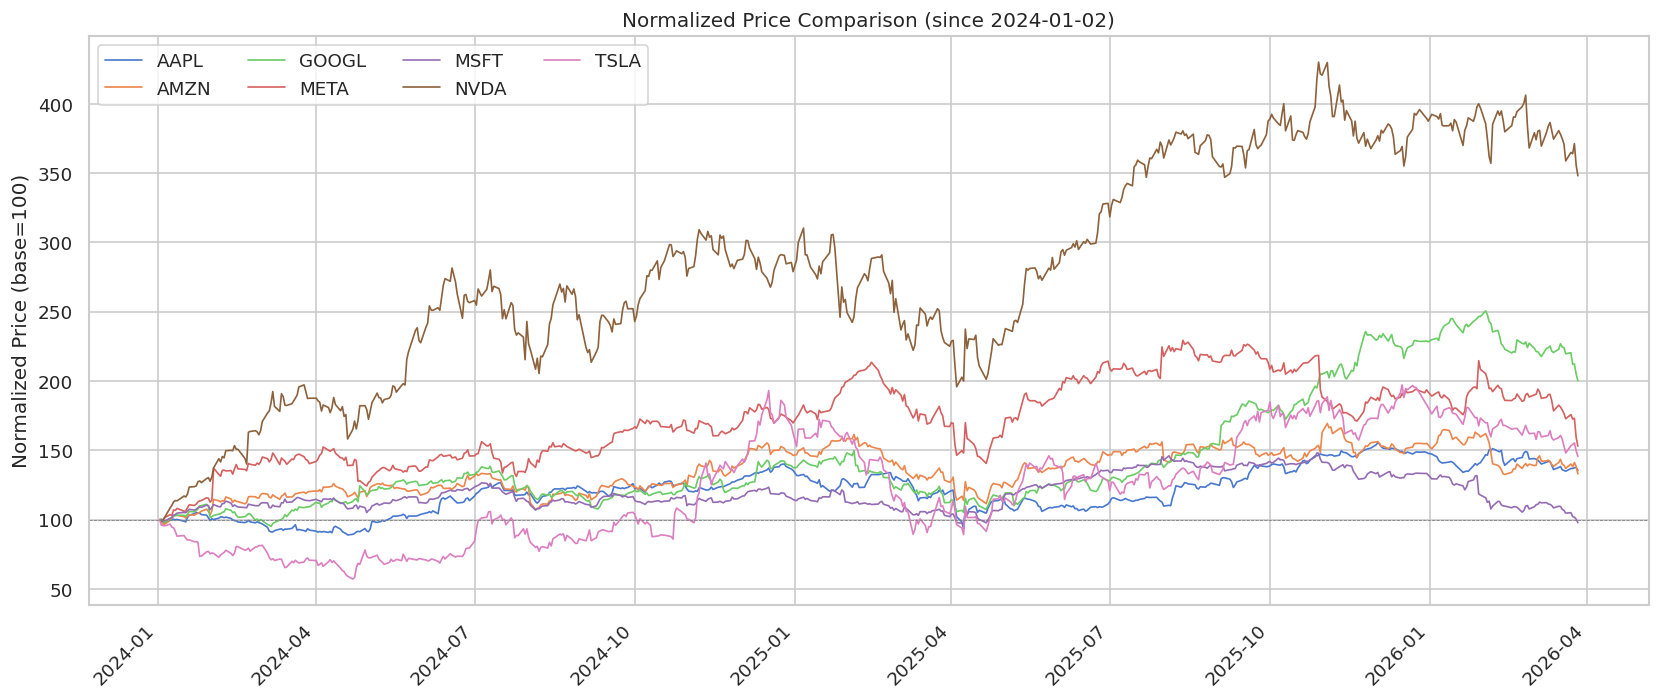

In [12]:
# Normalized comparison (base = 100)
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in tickers:
    subset = prices[prices["Ticker"] == ticker].sort_values("Date")
    base = subset["Adj Close"].iloc[0]
    ax.plot(subset["Date"], subset["Adj Close"] / base * 100, label=ticker, linewidth=1)

ax.axhline(100, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Normalized Price (base=100)")
ax.set_title("Normalized Price Comparison (since 2024-01-02)")
ax.legend(loc="upper left", ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7 — Tweet Volume & Timing

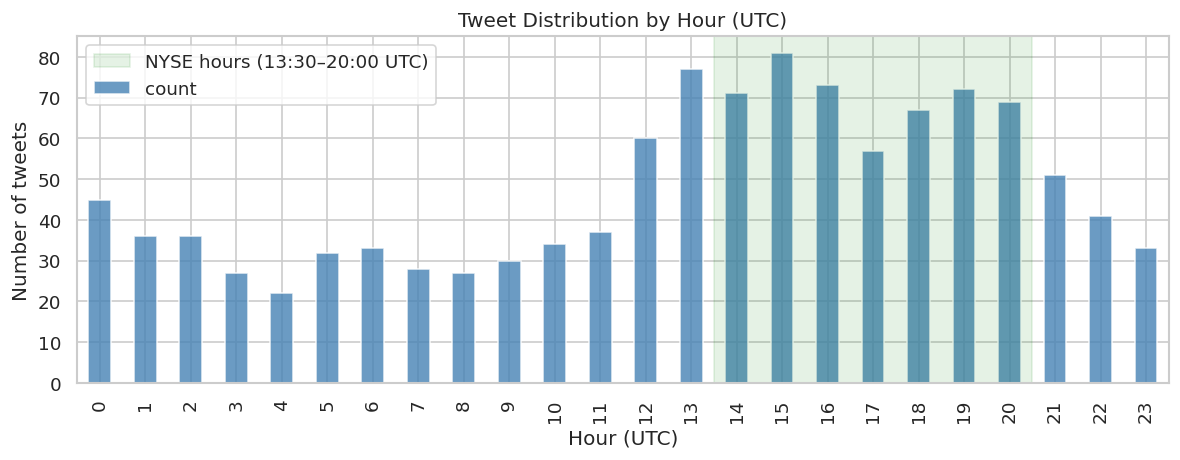

In [13]:
# Hourly distribution
tweets["hour"] = tweets["posted_at"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
tweets["hour"].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Distribution by Hour (UTC)")
ax.axvspan(13.5, 20.5, alpha=0.1, color="green", label="NYSE hours (13:30–20:00 UTC)")
ax.legend()
plt.tight_layout()
plt.show()

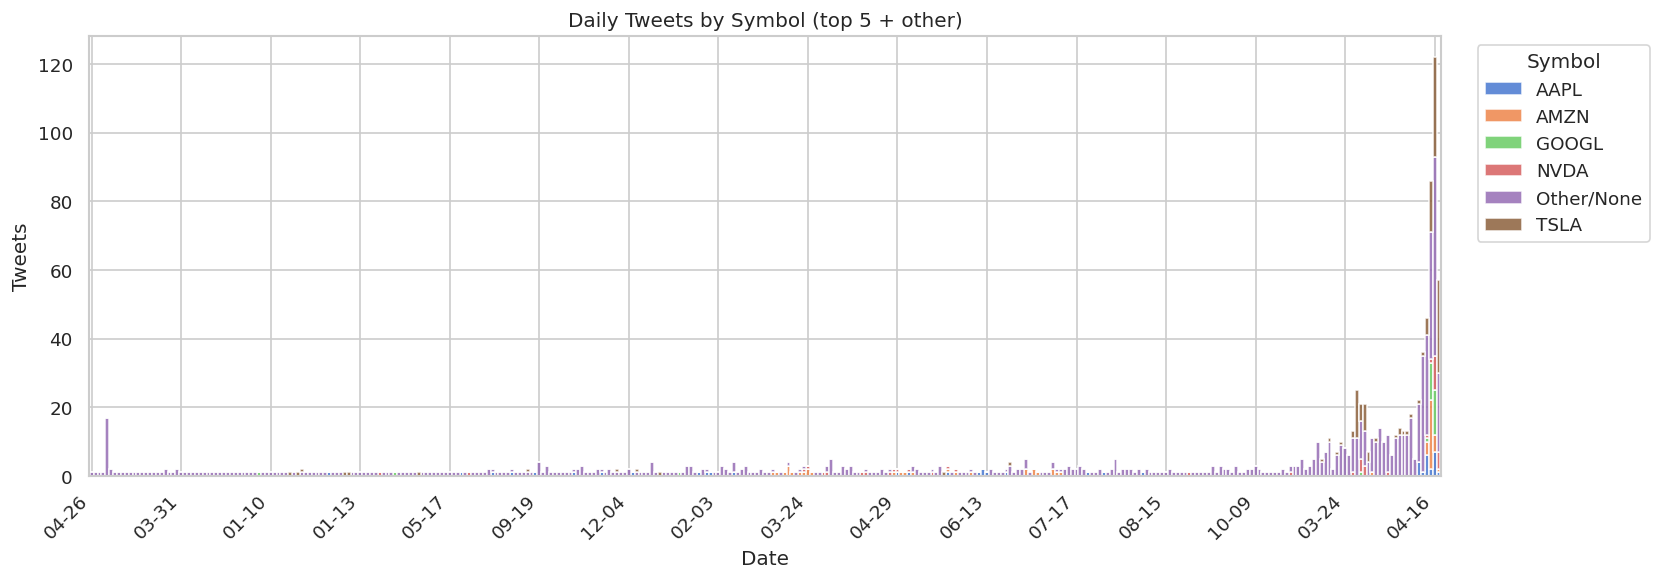

In [14]:
# Daily tweet volume stacked by top symbols
top5 = tweets["symbol"].value_counts().head(5).index.tolist()
tweets["symbol_group"] = tweets["symbol"].where(tweets["symbol"].isin(top5), other="Other/None")
tweets["date_dt"] = pd.to_datetime(tweets["date"])

daily_symbol = (
    tweets.groupby(["date_dt", "symbol_group"]).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
daily_symbol.plot.bar(stacked=True, ax=ax, width=1, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets")
ax.set_title("Daily Tweets by Symbol (top 5 + other)")
# Reduce x-tick clutter
n_ticks = len(daily_symbol)
step = max(1, n_ticks // 15)
ax.set_xticks(range(0, n_ticks, step))
ax.set_xticklabels(
    [d.strftime("%m-%d") for d in daily_symbol.index[::step]], rotation=45, ha="right"
)
ax.legend(title="Symbol", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8 — Tweet–Price Overlay (Top Tickers)

ConversionError: Failed to convert value(s) to axis units: [NaT, NaT]

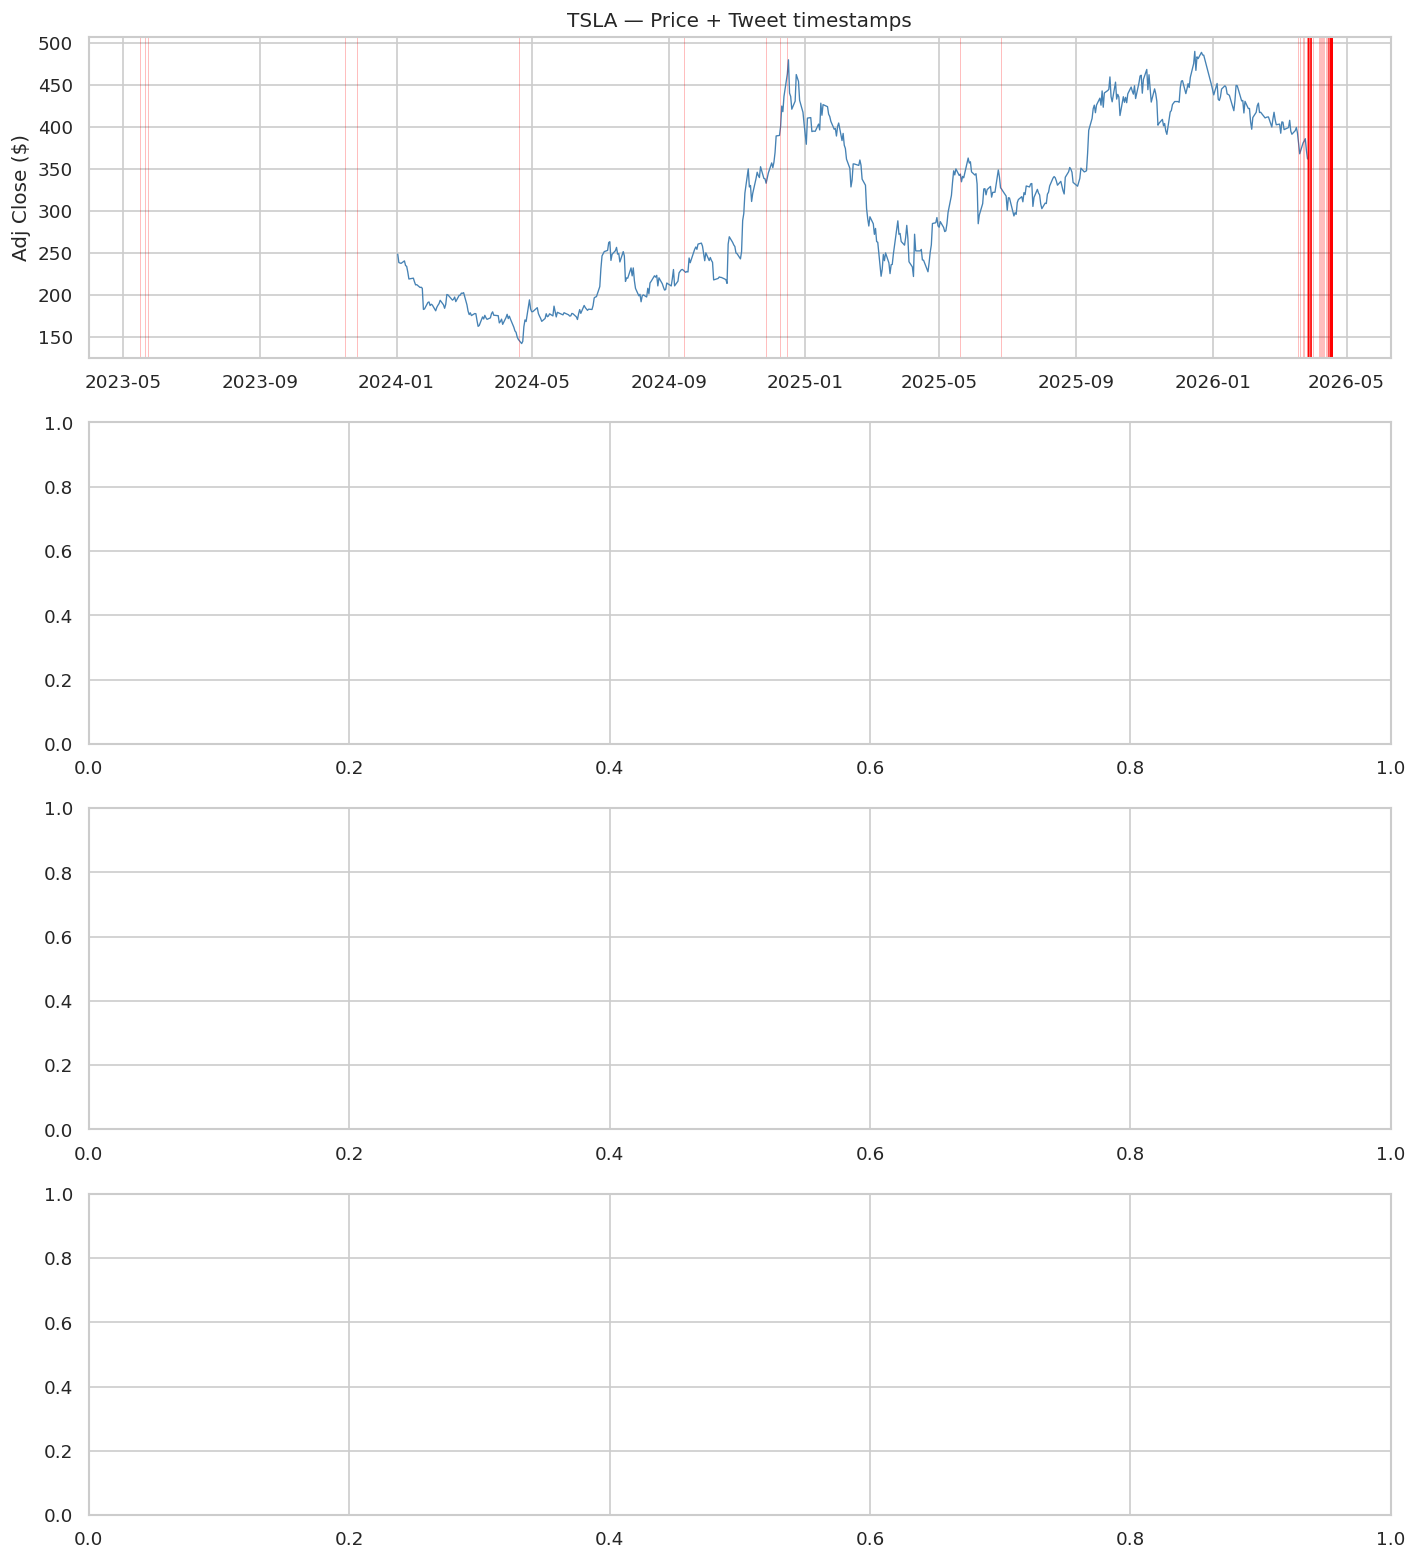

In [ ]:
# For each of the top tickers that appear in both tweets and CSV prices,
# plot the daily Adj Close with vertical lines for tweet timestamps.
from matplotlib.lines import Line2D

csv_tickers = set(prices["Ticker"].unique())
overlay_tickers = [t for t in top5 if t in csv_tickers][:4]

fig, axes = plt.subplots(len(overlay_tickers), 1, figsize=(14, 4 * len(overlay_tickers)), sharex=False)
if len(overlay_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, overlay_tickers):
    # Price line
    p = prices[prices["Ticker"] == ticker].sort_values("Date")
    ax.plot(p["Date"], p["Adj Close"], color="steelblue", linewidth=0.8, label="Adj Close")

    # Tweet markers
    tw = tweets[tweets["symbol"] == ticker]
    for _, row in tw.iterrows():
        ax.axvline(row["posted_at"], color="red", alpha=0.3, linewidth=0.5)

    ax.set_title(f"{ticker} — Price + Tweet timestamps")
    ax.set_ylabel("Adj Close ($)")
    # Use Line2D for legend (avoids pd.NaT crash with matplotlib date converter)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="red", alpha=0.5, linewidth=0.8))
    labels.append("Tweet")
    ax.legend(handles=handles, labels=labels, loc="upper left")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 9 — Follower & Engagement Analysis

In [ ]:
# Engagement vs. followers scatter (log scale)
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    merged["author_followers"].clip(lower=1),
    merged["total_engagement"].clip(lower=1),
    alpha=0.3, s=15, c="steelblue"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Author Followers (log)")
ax.set_ylabel("Total Engagement (likes + retweets, log)")
ax.set_title("Engagement vs. Follower Count")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 authors by tweet count
top_authors = tweets["author"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
top_authors.plot.barh(ax=ax, color="teal")
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Author")
ax.set_title("Top 10 Authors by Tweet Count")
ax.invert_yaxis()
for i, v in enumerate(top_authors.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 10 — Summary & Recommendations

In [ ]:
# Auto-generate key numbers for the summary
from IPython.display import Markdown, display

date_min = tweets["posted_at"].min()
date_max = tweets["posted_at"].max()

# Gap detection: days with 0 tweets
all_days = pd.date_range(date_min.normalize(), date_max.normalize(), freq="D")
active_days = set(tweets["posted_at"].dt.normalize())
gap_days = sorted(set(all_days) - active_days)

# Longest gap streak
if gap_days:
    gap_series = pd.Series(gap_days)
    gap_groups = (gap_series.diff().dt.days != 1).cumsum()
    longest_gap = gap_series.groupby(gap_groups).agg(["first", "last", "count"]).sort_values("count", ascending=False).iloc[0]
    gap_str = f"{longest_gap['first']:%Y-%m-%d} → {longest_gap['last']:%Y-%m-%d} ({int(longest_gap['count'])} days)"
else:
    gap_str = "None"

# New metrics from added sections
n_dup_content = tweets['content'].duplicated().sum()
n_empty = tweets['content'].isna().sum() + (tweets['content'].str.strip() == '').sum()
en_share = (tweets['lang'] == 'en').mean() if 'lang' in tweets.columns else float('nan')
n_outlier_returns = int(prices_sorted['is_outlier'].sum()) if 'is_outlier' in prices_sorted.columns else 0
n_td = int(tweets['is_trading_day'].sum()) if 'is_trading_day' in tweets.columns else 0
n_ntd = int((~tweets['is_trading_day']).sum()) if 'is_trading_day' in tweets.columns else 0
n_viral = int((merged['total_engagement'] >= merged['total_engagement'].quantile(0.95)).sum()) if 'total_engagement' in merged.columns else 0

summary = f"""
### Key Findings

| Metric | Value |
|--------|-------|
| Total tweets collected | {len(tweets):,} |
| Tweets with cashtag | {n_with_symbol:,} ({n_with_symbol/n_total:.1%}) |
| Unique symbols | {tweets['symbol'].nunique()} |
| Tweets with price snapshots | {n_with_prices:,} ({n_with_prices/len(tweets):.1%}) |
| Duplicate content tweets | {n_dup_content} |
| Empty / NaN content | {n_empty} |
| English tweet share | {en_share:.1%} |
| Viral tweets (≥P95 engagement) | {n_viral} |
| Tweets on trading days | {n_td} ({n_td/len(tweets):.1%}) |
| Tweets on non-trading days | {n_ntd} ({n_ntd/len(tweets):.1%}) |
| Tweet date range | {date_min:%Y-%m-%d} → {date_max:%Y-%m-%d} |
| Days with zero tweets | {len(gap_days)} |
| Longest gap | {gap_str} |
| Historical price tickers | {len(prices['Ticker'].unique())} |
| Price rows (CSV) | {len(prices):,} |
| Outlier returns (IQR×3) | {n_outlier_returns} |

### Recommendations

1. **Address the tweet gap**: The longest gap ({gap_str}) likely corresponds to the X bot-detection / session-expiry issue.
   Consider re-crawling or marking this period as missing in downstream analysis.
2. **Filter non-stock symbols**: Symbols like BTC, QUBIC, AKT are not equities — exclude them for stock-focused sentiment analysis.
3. **Focus analysis on top tickers**: The vast majority of tweets reference TSLA, AMZN, AAPL, NVDA, GOOGL.
   Sufficient volume exists only for these tickers.
4. **Handle after-hours tweets**: Many tweets fall outside NYSE trading hours, resulting in missing price snapshots.
   Decide whether to map to next-open or exclude.
5. **Next step → Sentiment labeling**: Run sentiment models on tweet content and align with price movements.
"""

display(Markdown(summary))